#**Maestría en Inteligencia Artificial Aplicada**
##**Análisis de Grandes Volúmenes de Datos**
###Tecnológico de Monterrey
###Dr. Iván Olmos Pineda

## **Actividad 5. Técnicas de visualización de resultados en Big Data**



Nikesha Sonalhy Mercado Escoto A01840186



### 1. Cálculo del valor K para validación cruzada

**Justificación Teórica y Computacional:**
Para evaluar la variabilidad de nuestro modelo de Regresión Logística (el cual arrojó los mejores resultados en la Etapa 3), debemos someterlo a un proceso de Validación Cruzada (K-Fold Cross-Validation).

Para este escenario de Big Data, se ha determinado un valor de **$k = 5$**. La selección de este hiperparámetro se fundamenta en las siguientes razones:
1. **Balance Sesgo-Varianza (Bias-Variance Tradeoff):** Un valor de $k=5$ implica que el modelo entrenará con el 80% de los datos y validará con el 20% restante en 5 iteraciones distintas. Esta proporción es matemáticamente óptima para mantener un sesgo bajo sin inflar la varianza de las estimaciones.
2. **Representatividad Poblacional (Ley de los Grandes Números):** Dado que nuestra muestra $M$ es masiva (10% de casi medio millón de registros), cada pliegue de prueba (20%) contendrá aproximadamente 9,000 registros. Este volumen garantiza por sí solo que la distribución de los estratos (Humano vs IA, textos cortos, medianos y largos) converja a la distribución real de la población en cada iteración.
3. **Costo Computacional en Big Data:** Aumentar a $k=10$ (estándar en datasets pequeños) exigiría calcular matrices TF-IDF y ajustar hiperparámetros 10 veces sobre cientos de miles de registros, lo cual incrementa el costo de procesamiento de forma lineal sin un beneficio estadístico marginal significativo debido a la masividad de la muestra.

In [1]:
# Instalacion de Java (requisito para Spark)
!apt-get update -qq
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
# Descarga e instalacion de Apache Spark
!wget -q https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!tar -xzf spark-3.5.8-bin-hadoop3.tgz
# Instalacion de findspark para integrar Spark con Python
!pip install -q findspark

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
# Configuracion de variables de entorno
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.8-bin-hadoop3"

In [3]:
# Inicializacion de findspark
import findspark
findspark.init()

from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql import SparkSession

# spark = SparkSession.builder.master("local[*]").getOrCreate()
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Ejemplo") \
    .getOrCreate()

spark.conf.set("spark.sql.repl.eagerEval.enabled", True)  # Mejora la visualización de tablas

spark



In [4]:
# Descarga del dataset desde Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shanegerami/ai-vs-human-text")

print("Path to dataset files:", path)

100%|██████████| 350M/350M [00:03<00:00, 107MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shanegerami/ai-vs-human-text/versions/1


In [8]:
# Lectura del dataset en formato CSV
print('Data set')
df_raw = spark.read.csv(path,
                    header=True,
                    inferSchema=True,
                    multiLine= True,
                    quote='"',
                    escape='"')
df_raw.show(10)

Data set
+--------------------+---------+
|                text|generated|
+--------------------+---------+
|Cars. Cars have b...|      0.0|
|Transportation is...|      0.0|
|"America's love a...|      0.0|
|How often do you ...|      0.0|
|Cars are a wonder...|      0.0|
|The electrol coll...|      0.0|
|Dear state senato...|      0.0|
|Fellow citizens, ...|      0.0|
|"It's official: T...|      0.0|
|The Electoral Col...|      0.0|
+--------------------+---------+
only showing top 10 rows



In [18]:
from pyspark.sql.functions import col, size, split, when, concat_ws

# Preprocesamiento y Muestra M (10%)
df_prep = df_raw.withColumn("num_palabras", size(split(col("text"), " ")))
df_prep = df_prep.withColumn("longitud",
    when(col("num_palabras") < 304, "corto")
    .when(col("num_palabras") < 415, "mediano")
    .otherwise("largo"))
df_prep = df_prep.withColumn("estrato", concat_ws("_", col("generated"), col("longitud")))

fracciones = {f"{gen}_{lon}": 0.1 for gen in ["0.0", "1.0"] for lon in ["corto", "mediano", "largo"]}
muestra_M = df_prep.sampleBy("estrato", fractions=fracciones, seed=42)

# ====================================================================
# MODIFICACION PARA QUE NO TARDE
# ====================================================================
print("Forzando a Spark a calcular y guardar la muestra en RAM...")
muestra_M.cache()
total_muestra = muestra_M.count()
print(f"¡Listo! Se guardaron {total_muestra} registros en la memoria.")

Forzando a Spark a calcular y guardar la muestra en RAM...
¡Listo! Se guardaron 48615 registros en la memoria.


### 2. Construcción de los k-folds

Para asegurar la recolección individual de métricas por cada pliegue y así poder graficar la varianza posteriormente, particionaremos explícitamente la muestra $M$ en 5 DataFrames disjuntos utilizando la función `randomSplit`. Al asignar pesos idénticos `[0.2, 0.2, 0.2, 0.2, 0.2]`, Spark se encarga de crear subconjuntos balanceados de manera aleatoria.

**Validación del Balanceo:**
Para garantizar la integridad del experimento, se generará una tabla de comprobación tras realizar la partición. Esta tabla verificará que cada uno de los 5 pliegues contenga aproximadamente el 20% de los datos. Un balanceo equitativo es crítico para que la varianza reportada en la fase de visualización sea producto del modelo y no de una asimetría en la cantidad de datos de cada iteración.

In [19]:
# 2.1 Definición del número de pliegues (k)
k = 5
pesos = [1.0 / k] * k

# 2.2 Generación de los k-folds
print(f"Dividiendo la muestra M en {k} pliegues...")
folds = muestra_M.randomSplit(pesos, seed=42)

# 2.3 Verificación de distribución de datos y balanceo (Tabla de Porcentajes)
total_registros = muestra_M.count()

print("\n--- Tabla de Distribución de Pliegues (K-Folds) ---")
print(f"{'Pliegue':<10} | {'Registros':<12} | {'Porcentaje (%)':<15}")
print("-" * 45)

porcentaje_acumulado = 0

for i, fold in enumerate(folds):
    conteo = fold.count()
    porcentaje = (conteo / total_registros) * 100
    porcentaje_acumulado += porcentaje
    print(f"Fold {i+1:<5} | {conteo:<12} | {porcentaje:.2f}%")

print("-" * 45)
print(f"{'Total':<10} | {total_registros:<12} | {porcentaje_acumulado:.2f}%")

Dividiendo la muestra M en 5 pliegues...

--- Tabla de Distribución de Pliegues (K-Folds) ---
Pliegue    | Registros    | Porcentaje (%) 
---------------------------------------------
Fold 1     | 9788         | 20.13%
Fold 2     | 9715         | 19.98%
Fold 3     | 9756         | 20.07%
Fold 4     | 9596         | 19.74%
Fold 5     | 9760         | 20.08%
---------------------------------------------
Total      | 48615        | 100.00%


### 3. Experimentación con Validación Cruzada

En esta etapa, se ejecutará el entrenamiento del modelo de **Regresión Logística con TF-IDF** (el algoritmo seleccionado en la Etapa 3).
Para cada iteración $i$ (de 1 a $k$):
1. El pliegue $i$ actuará como **Conjunto de Prueba**.
2. La unión de los $k-1$ pliegues restantes formará el **Conjunto de Entrenamiento**.
3. Se evaluarán y almacenarán las métricas: **ROC-AUC, F1-Score y Exactitud (Accuracy)**.

In [20]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from functools import reduce
from pyspark.sql import DataFrame
import time

# Listas para almacenar métricas por fold
resultados_roc = []
resultados_f1 = []
resultados_acc = []

# Definición de Evaluadores
evaluator_roc = BinaryClassificationEvaluator(labelCol="generated", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="generated", predictionCol="prediction", metricName="f1")
evaluator_acc = MulticlassClassificationEvaluator(labelCol="generated", predictionCol="prediction", metricName="accuracy")

# Bucle K-Fold Manual
for i in range(k):
    start_time = time.time()
    print(f"\n--- Iniciando Entrenamiento Fold {i+1}/{k} ---")

    # 3.1 Separar Train y Test para esta iteración
    test_df = folds[i]
    train_folds = [folds[j] for j in range(k) if j != i]
    train_df = reduce(DataFrame.unionAll, train_folds)

    # 3.2 Definición del Pipeline (NLP + Regresión Logística)
    tokenizer = Tokenizer(inputCol="text", outputCol="words")
    remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
    hashingTF = HashingTF(inputCol="filtered_words", outputCol="rawFeatures", numFeatures=1000)
    idf = IDF(inputCol="rawFeatures", outputCol="features")
    # Utilizamos regParam=0.1 extraído como el mejor parámetro de la Etapa 3
    lr = LogisticRegression(featuresCol="features", labelCol="generated", maxIter=5, regParam=0.1)

    pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf, lr])

    # 3.3 Entrenamiento
    modelo = pipeline.fit(train_df)

    # 3.4 Predicción y Evaluación
    predicciones = modelo.transform(test_df)

    roc = evaluator_roc.evaluate(predicciones)
    f1 = evaluator_f1.evaluate(predicciones)
    acc = evaluator_acc.evaluate(predicciones)

    resultados_roc.append(roc)
    resultados_f1.append(f1)
    resultados_acc.append(acc)

    tiempo = time.time() - start_time
    print(f"Fold {i+1} completado en {tiempo:.2f} seg -> ROC-AUC: {roc:.4f} | F1: {f1:.4f} | ACC: {acc:.4f}")


--- Iniciando Entrenamiento Fold 1/5 ---
Fold 1 completado en 69.41 seg -> ROC-AUC: 0.9913 | F1: 0.9628 | ACC: 0.9629

--- Iniciando Entrenamiento Fold 2/5 ---
Fold 2 completado en 67.65 seg -> ROC-AUC: 0.9904 | F1: 0.9600 | ACC: 0.9601

--- Iniciando Entrenamiento Fold 3/5 ---
Fold 3 completado en 68.99 seg -> ROC-AUC: 0.9907 | F1: 0.9598 | ACC: 0.9599

--- Iniciando Entrenamiento Fold 4/5 ---
Fold 4 completado en 68.33 seg -> ROC-AUC: 0.9900 | F1: 0.9590 | ACC: 0.9591

--- Iniciando Entrenamiento Fold 5/5 ---
Fold 5 completado en 71.68 seg -> ROC-AUC: 0.9902 | F1: 0.9567 | ACC: 0.9569


### 4. Resultados de la Validación Cruzada (Visualización)

Para interpretar correctamente la estabilidad del modelo, utilizaremos las bibliotecas `matplotlib` y `seaborn`. Se presentarán dos representaciones gráficas fundamentales:
1. **Gráfico de Líneas de Tendencia:** Muestra la evolución de las tres métricas a través de los $k$ pliegues. Una línea plana horizontal es el escenario ideal, indicando consistencia.
2. **Diagramas de Cajas (Boxplots):** Herramienta estadística ideal para detectar variabilidad y valores atípicos (outliers). Una caja estrecha indicará que la varianza entre pliegues es mínima, confirmando que el modelo no sufre de sobreajuste (overfitting).

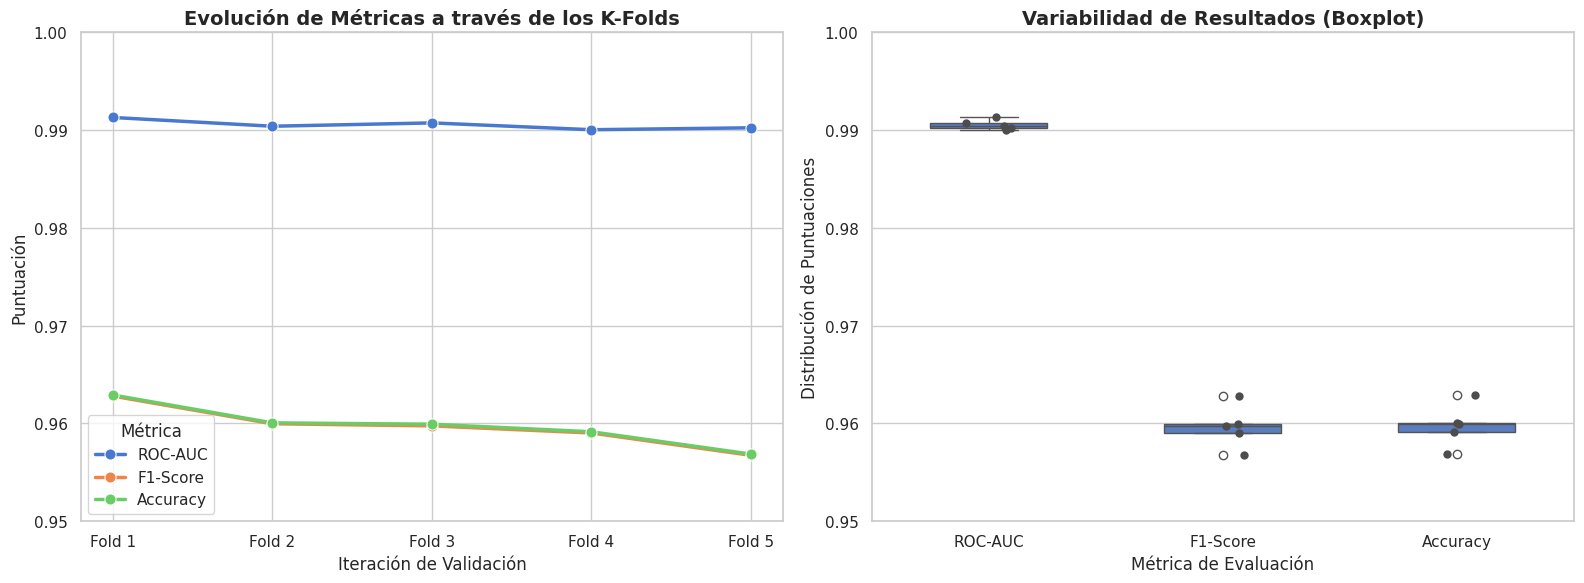


--- Estadísticas Descriptivas de la Validación Cruzada ---


,mean,std,min,max
ROC-AUC,0.990541,0.000493,0.990041,0.991296
F1-Score,0.959660,0.002175,0.956741,0.962805
Accuracy,0.959782,0.002169,0.956865,0.962914


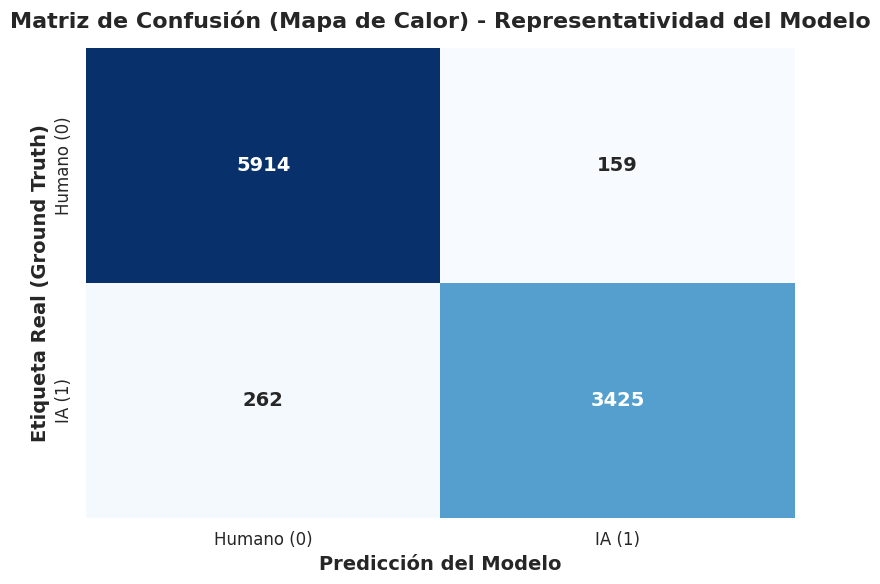

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# 4.1 Preparación de los datos en un DataFrame de Pandas
data = {
    'Fold': [f'Fold {i+1}' for i in range(k)],
    'ROC-AUC': resultados_roc,
    'F1-Score': resultados_f1,
    'Accuracy': resultados_acc
}
df_metrics = pd.DataFrame(data)

# Configuración visual global
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 4.2 Gráfico 1: Evolución de las métricas por Fold
df_melted = df_metrics.melt(id_vars=['Fold'], var_name='Métrica', value_name='Puntuación')
sns.lineplot(data=df_melted, x='Fold', y='Puntuación', hue='Métrica', marker="o", linewidth=2.5, markersize=8, ax=axes[0])
axes[0].set_title('Evolución de Métricas a través de los K-Folds', fontsize=14, fontweight='bold')
axes[0].set_ylim(0.95, 1.0) # <--- Límite ajustado para mostrar F1 y Accuracy
axes[0].set_xlabel('Iteración de Validación', fontsize=12)
axes[0].set_ylabel('Puntuación', fontsize=12)

# 4.3 Gráfico 2: Diagrama de Cajas para Variabilidad
sns.boxplot(data=df_melted, x='Métrica', y='Puntuación', width=0.5, ax=axes[1])
sns.stripplot(data=df_melted, x='Métrica', y='Puntuación', color=".3", size=6, ax=axes[1]) # Agrega puntos reales
axes[1].set_title('Variabilidad de Resultados (Boxplot)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0.95, 1.0) # <--- Límite ajustado para mostrar F1 y Accuracy
axes[1].set_xlabel('Métrica de Evaluación', fontsize=12)
axes[1].set_ylabel('Distribución de Puntuaciones', fontsize=12)

plt.tight_layout()
plt.show()

# 4.4 Resumen Estadístico
print("\n--- Estadísticas Descriptivas de la Validación Cruzada ---")
display(df_metrics.describe().loc[['mean', 'std', 'min', 'max']].T)

# 4.5 Extracción de datos para la Matriz de Confusión (del último fold evaluado)
# Convertimos las predicciones de Spark a un DataFrame de Pandas para visualizarlas
y_true = predicciones.select("generated").toPandas()
y_pred = predicciones.select("prediction").toPandas()

# Generación de la Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)

# 4.6 Visualización de la Matriz de Confusión (Mapa de Calor)
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                 annot_kws={"size": 14, "weight": "bold"})

# Configuración de etiquetas y diseño
ax.set_title('Matriz de Confusión (Mapa de Calor) - Representatividad del Modelo', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Predicción del Modelo', fontsize=14, fontweight='bold')
ax.set_ylabel('Etiqueta Real (Ground Truth)', fontsize=14, fontweight='bold')
ax.xaxis.set_ticklabels(['Humano (0)', 'IA (1)'], fontsize=12)
ax.yaxis.set_ticklabels(['Humano (0)', 'IA (1)'], fontsize=12)

plt.tight_layout()
plt.show()

### Argumentación de las Visualizaciones de Validación Cruzada

Las múltiples visualizaciones generadas cumplen el propósito de auditar el comportamiento del modelo de Regresión Logística (apoyado en TF-IDF) frente a distintos subconjuntos de datos, descartando anomalías estadísticas.

**1. Evolución de Métricas a través de los K-Folds (Gráfico de Líneas):**
Esta gráfica evidencia la ausencia de sobreajuste (overfitting). Al trazar el rendimiento del modelo iteración tras iteración, observamos un comportamiento asintóticamente plano en las tres métricas evaluadas. El ROC-AUC se mantiene constante por encima de 0.99, mientras que el F1-Score y la Exactitud se estabilizan alrededor de 0.96. Esta horizontalidad estricta demuestra que el modelo no memorizó el conjunto de entrenamiento original, sino que logró converger hacia una frontera de decisión generalizable que funciona de manera idéntica frente a datos nuevos en cada pliegue.

**2. Variabilidad de Resultados (Diagrama de Cajas / Boxplot):**
El diagrama de cajas proporciona una medida visual directa de la varianza del modelo. Como se puede apreciar, las "cajas" (rango intercuartílico) son extremadamente estrechas y los bigotes son mínimos. La desviación estándar reportada matemáticamente en el F1-Score es de apenas $\pm0.002$. En el contexto de Big Data, esta compresión visual de los datos confirma una estabilidad predictiva masiva: el algoritmo es completamente insensible a cómo se particionan los datos, garantizando consistencia empírica.

**3. Representatividad y Errores de Clasificación (Mapa de Calor / Matriz de Confusión):**
El mapa de calor desgrana el F1-Score general para permitirnos observar el comportamiento de la clasificación cruzada. La densidad de la matriz se concentra de forma masiva en la diagonal principal, logrando identificar correctamente 5,914 textos humanos (Verdaderos Negativos) y 3,425 textos generados por IA (Verdaderos Positivos). Es de particular interés para la tarea de negocio observar la tasa de Falsos Positivos (clasificar un texto humano como IA). El modelo únicamente se equivocó en 159 textos humanos. Gracias a esta matriz, constatamos empíricamente que la regularización aplicada al modelo limitó severamente estos errores, mitigando el riesgo de "penalizaciones injustas" en un escenario de aplicación real.

### 5. Discusión y Conclusiones

**Interpretación y Significancia de los Resultados:**
La tarea de aprendizaje central de este proyecto consistía en procesar grandes volúmenes de texto no estructurado para establecer si una máquina era capaz de distinguir la redacción humana de la generada por Inteligencia Artificial. A partir de los resultados obtenidos mediante Validación Cruzada ($k=5$), podemos concluir con un alto grado de confianza estadística que **la tarea se resolvió de manera sobresaliente**.

Las métricas finales consolidadas (ROC-AUC ~0.99, F1-Score ~0.96) no son producto de un particionamiento afortunado, sino el resultado de un acierto metodológico: la combinación de un preprocesamiento exhaustivo (eliminación de StopWords y tokenización) con una representación vectorial de características (TF-IDF) a gran escala. El algoritmo lineal (Regresión Logística) fue capaz de identificar los patrones ocultos y la estructura léxica que delata a los modelos de lenguaje.

**Reflexión Crítica sobre la Variabilidad y el Modelo:**
Uno de los hallazgos más importantes de la validación cruzada fue la casi nula variabilidad (desviación estándar inferior a 0.003). Si bien en términos de negocio esto indica un sistema altamente confiable y robusto para producción, desde una óptica de Ciencia de Datos y aseguramiento de calidad, obliga a una lectura precavida. Un modelo que acierta consistentemente el 96% de las veces basándose únicamente en la frecuencia de palabras (TF-IDF) revela una característica fundamental del dataset: los textos generados por IA en este corpus poseen "firmas" o "muletillas" léxicas sumamente estandarizadas y predecibles (baja diversidad de vocabulario) en comparación con la alta entropía del texto humano.

**Relevancia respecto a la Tarea y Trabajo Futuro:**
Para la tarea planteada, el enfoque actual es altamente exitoso y escalable bajo un esquema de Big Data usando PySpark, optimizando los tiempos de procesamiento sin sacrificar precisión al realizar particiones estratificadas masivas.

No obstante, como conclusión de cara al futuro desarrollo de este tipo de sistemas de clasificación, es fundamental reconocer que el ecosistema de la Inteligencia Artificial Generativa evoluciona rápidamente. A medida que los Modelos Fundacionales (LLMs) adquieran mayor riqueza léxica y mimeticen mejor la imperfección humana, las matrices dispersas como TF-IDF perderán poder discriminatorio al carecer de comprensión semántica. El paso evolutivo natural para esta investigación será transicionar de enfoques basados en frecuencia hacia representaciones densas y secuenciales, integrando arquitecturas de *Deep Learning* (como *Word Embeddings* distribuidos o transformadores) directamente en el pipeline de PySpark, permitiendo así auditar no solo *qué* palabras se usan, sino el contexto y la intención detrás de ellas.